In [1]:
import numpy as npS
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.decomposition import PCA, KernelPCA
from sklearn.svm import SVC

In [2]:
X, y = make_circles(n_samples=500, factor=0.3, noise=0.05, random_state=42)

In [3]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

In [4]:
kpca = KernelPCA(n_components=2, kernel='rbf', gamma=10)
X_kpca = kpca.fit_transform(X)

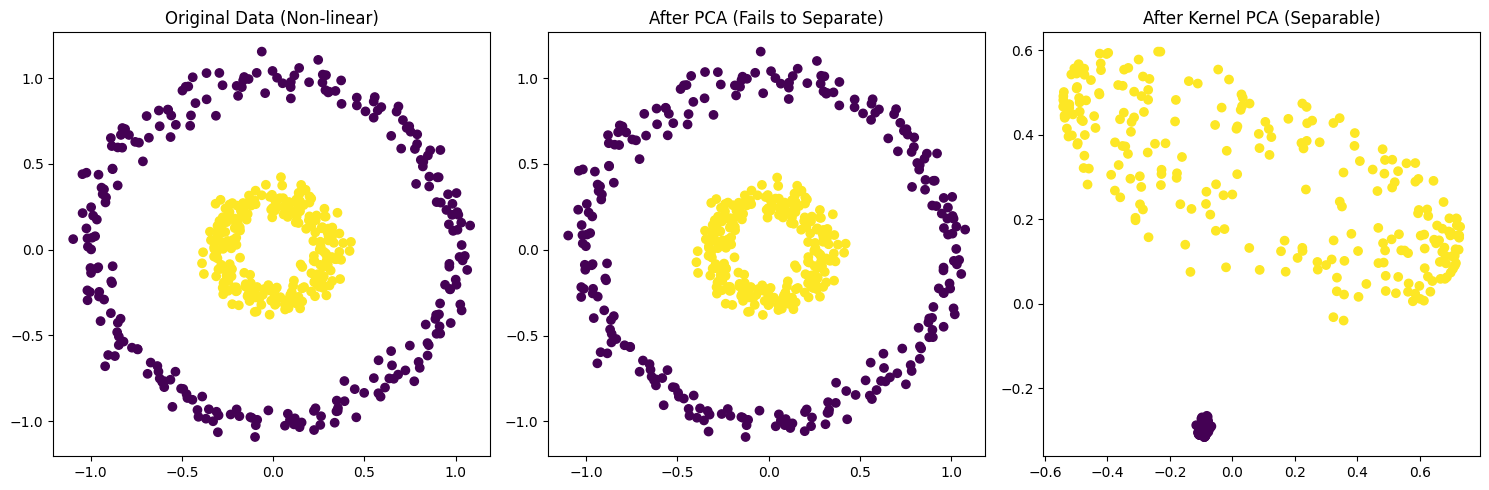

In [7]:
plt.figure(figsize=(15, 5))

# Original Data
plt.subplot(1, 3, 1)
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Original Data (Non-linear)")

# PCA Result
plt.subplot(1, 3, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y)
plt.title("After PCA (Fails to Separate)")

# Kernel PCA Result
plt.subplot(1, 3, 3)
plt.scatter(X_kpca[:, 0], X_kpca[:, 1], c=y)
plt.title("After Kernel PCA (Separable)")

plt.tight_layout()
plt.show()

In [8]:
clf_pca = SVC(kernel='linear')
clf_pca.fit(X_pca, y)
acc_pca = clf_pca.score(X_pca, y)

clf_kpca = SVC(kernel='linear')
clf_kpca.fit(X_kpca, y)
acc_kpca = clf_kpca.score(X_kpca, y)

print("Accuracy with PCA:", acc_pca)
print("Accuracy with Kernel PCA:", acc_kpca)

Accuracy with PCA: 0.68
Accuracy with Kernel PCA: 1.0


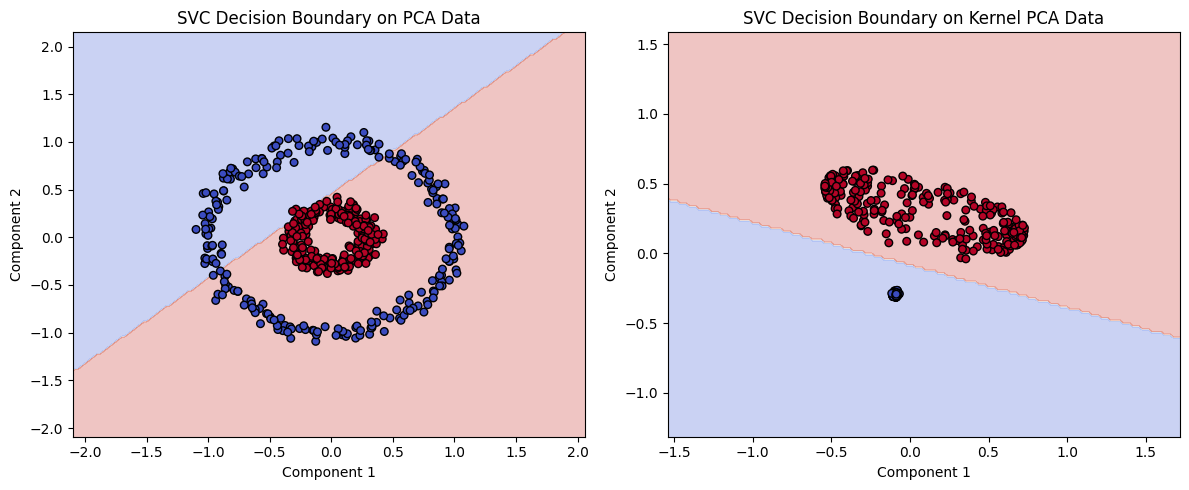

In [9]:
def plot_decision_boundary(X_transformed, y_true, classifier, title):
    # Create a mesh to plot in
    x_min, x_max = X_transformed[:, 0].min() - 1, X_transformed[:, 0].max() + 1
    y_min, y_max = X_transformed[:, 1].min() - 1, X_transformed[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    Z = classifier.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    plt.scatter(X_transformed[:, 0], X_transformed[:, 1], c=y_true, s=30, edgecolor='k', cmap=plt.cm.coolwarm)
    plt.title(title)
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plot_decision_boundary(X_pca, y, clf_pca, "SVC Decision Boundary on PCA Data")

plt.subplot(1, 2, 2)
plot_decision_boundary(X_kpca, y, clf_kpca, "SVC Decision Boundary on Kernel PCA Data")

plt.tight_layout()
plt.show()

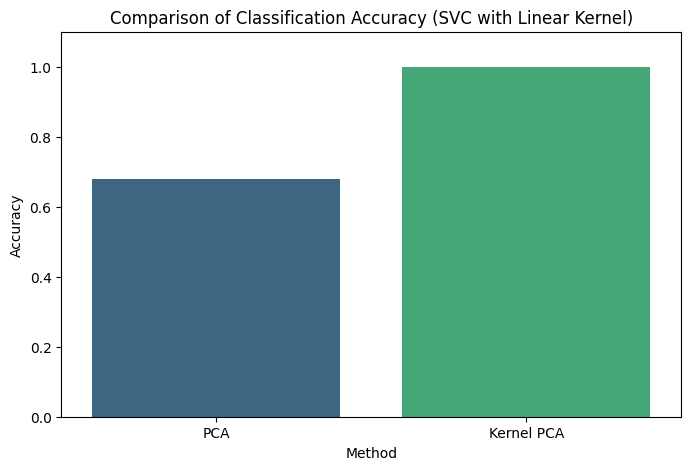

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

accuracies = {'PCA': acc_pca, 'Kernel PCA': acc_kpca}
accuracy_df = pd.DataFrame(accuracies.items(), columns=['Method', 'Accuracy'])

plt.figure(figsize=(8, 5))
sns.barplot(x='Method', y='Accuracy', hue='Method', data=accuracy_df, palette='viridis', legend=False)
plt.title('Comparison of Classification Accuracy (SVC with Linear Kernel)')
plt.ylim(0, 1.1) # Set y-axis limit slightly above 1 for better visualization
plt.ylabel('Accuracy')
plt.show()

### Conclusion

This analysis clearly demonstrates the effectiveness of Kernel PCA over standard PCA when dealing with non-linearly separable data. While PCA struggled to find a linear projection that allowed for effective classification, Kernel PCA successfully transformed the data into a higher-dimensional feature space where it became linearly separable, leading to perfect classification accuracy. This highlights the importance of choosing the right dimensionality reduction technique based on the underlying structure of the data.